<a href="https://colab.research.google.com/github/anirbanghoshsbi/.github.io/blob/master/work/err/cross_section_momentum/ON%20ENTIRE%20EQUITY/cross_sectional_momentum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import duckdb
import numpy as np

In [4]:
# Reconnect and load data from DuckDB
conn = duckdb.connect("candle_data.duckdb")

# Read data into a Pandas DataFrame
df = conn.execute("SELECT * FROM candle_table").df()

# Close connection
conn.close()

# Display first few rows
print(df.shape)

(13278, 51)


In [5]:
df.tail(3)

,date,ADANIENT,ADANIPORTS,APOLLOHOSP,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJFINANCE,BAJAJFINSV,BPCL,...,SUNPHARMA,TCS,TATACONSUM,TATAMOTORS,TATASTEEL,TECHM,TITAN,UPL,ULTRACEMCO,WIPRO
13275,2026-03-11,1974.699951,1410.800049,7684.0,2232.000000,1255.800049,9327.5,893.650024,1795.300049,325.05,...,1825.900024,2464.899902,1073.400024,NaN,194.740005,1334.400024,4140.299805,625.849976,11462.0,202.229996
13276,2026-03-12,2002.000000,1391.500000,7574.5,2221.199951,1234.500000,9162.0,863.099976,1770.800049,326.35,...,1825.300049,2442.399902,1057.800049,NaN,193.470001,1349.800049,4129.600098,629.049988,11089.0,202.509995
13277,2026-03-13,1961.099976,1363.199951,7550.0,2196.800049,1197.300049,8875.0,855.049988,1738.000000,319.3,...,1801.599976,2410.500000,1083.599976,NaN,183.509995,1332.800049,4073.199951,609.400024,10616.0,197.580002


In [6]:
df = df.copy()

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df = df.set_index('date')

In [9]:
# -----------------------------
# 1. Ensure proper date format
# -----------------------------

df = df.apply(pd.to_numeric, errors='coerce')
# -----------------------------
# 2. Calculate 6-Month Momentum
# 6 months ≈ 126 trading days
# -----------------------------
lookback = 126

momentum_6m = df.pct_change(periods=lookback)

# -----------------------------
# 3. Take Latest Date Snapshot
# -----------------------------
latest_momentum = momentum_6m.iloc[-1]

# Drop NaNs (stocks without sufficient history)
latest_momentum = latest_momentum.dropna()

# -----------------------------
# 4. Cross-Sectional Ranking
# -----------------------------
top_10 = (
    latest_momentum
    .sort_values(ascending=False)
    .head(10)
)

# -----------------------------
# 5. Display Results
# -----------------------------
result = pd.DataFrame({
    'symbol': top_10.index,
    'momentum_6m': top_10.values
})

print("Top 10 Nifty 50 Stocks by 6-Month Momentum")
print(result)

Top 10 Nifty 50 Stocks by 6-Month Momentum
       symbol  momentum_6m
0   COALINDIA     0.081394
1  APOLLOHOSP     0.060095
2   SUNPHARMA     0.058146
3        NTPC     0.047548
4   POWERGRID     0.040090
5     DRREDDY     0.038075
6  TATAMOTORS     0.000000
7       TITAN    -0.005955
8   BRITANNIA    -0.010561
9    DIVISLAB    -0.011479


/tmp/ipykernel_162/3025169071.py:12: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  momentum_6m = df.pct_change(periods=lookback)


In [10]:
stocks = [
    "COALINDIA",
    "APOLLOHOSP",
    "SUNPHARMA",
    "NTPC",
    "POWERGRID",
    "DRREDDY",
    "TATAMOTORS",
    "TITAN",
    "BRITANNIA",
    "DIVISLAB"
]

df_subset = df[df["symbol"].isin(stocks)]

KeyError: 'symbol'

In [11]:
df.head()

,ADANIENT,ADANIPORTS,APOLLOHOSP,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJFINANCE,BAJAJFINSV,BPCL,BHARTIARTL,...,SUNPHARMA,TCS,TATACONSUM,TATAMOTORS,TATASTEEL,TECHM,TITAN,UPL,ULTRACEMCO,WIPRO
date,,,,,,,,,,,,,,,,,,,,,
2020-03-25,132.300003,255.600006,1183.75,1593.150024,326.799988,1946.75,2585.600098,483.029999,NaN,429.100006,...,347.649994,1750.300049,277.149994,70.25,28.68,526.700012,880.799988,280.869995,3228.600098,87.330002
2020-03-25,132.300003,255.600006,1183.75,1593.150024,326.799988,1946.75,2585.600098,483.029999,136.88,429.100006,...,347.649994,1750.300049,277.149994,70.25,28.68,526.700012,880.799988,280.869995,3228.600098,87.330002
2020-03-25,132.300003,255.600006,1183.75,1593.150024,326.799988,1946.75,2585.600098,483.029999,136.88,429.100006,...,347.649994,1750.300049,277.149994,70.25,28.68,526.700012,880.799988,280.869995,3228.600098,87.330002
2020-03-25,132.300003,255.600006,1183.75,1593.150024,326.799988,1946.75,2585.600098,483.029999,136.88,429.100006,...,347.649994,1750.300049,277.149994,70.25,28.68,526.700012,880.799988,280.869995,3228.600098,87.330002
2020-03-25,132.300003,255.600006,1183.75,1593.150024,326.799988,1946.75,2585.600098,483.029999,136.88,429.100006,...,347.649994,1750.300049,277.149994,70.25,28.68,526.700012,880.799988,280.869995,3228.600098,87.330002


In [17]:
stocks = [
    "APOLLOHOSP",  # top Quality Stocks from nifty 50
    'BRITANNIA',
    'DIVISLAB',
    'EICHERMOT',
    'JSWSTEEL',
    'TITAN',
    ]

df_momentum = df.loc[:, df.columns.intersection(stocks)]

In [18]:
returns = df_momentum.pct_change().dropna()

weights = np.repeat(1/len(df_momentum.columns), len(df_momentum.columns))

portfolio_returns = returns.dot(weights)

equal_weight_index = (1 + portfolio_returns).cumprod() * 100

/tmp/ipykernel_162/1372570529.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df_momentum.pct_change().dropna()


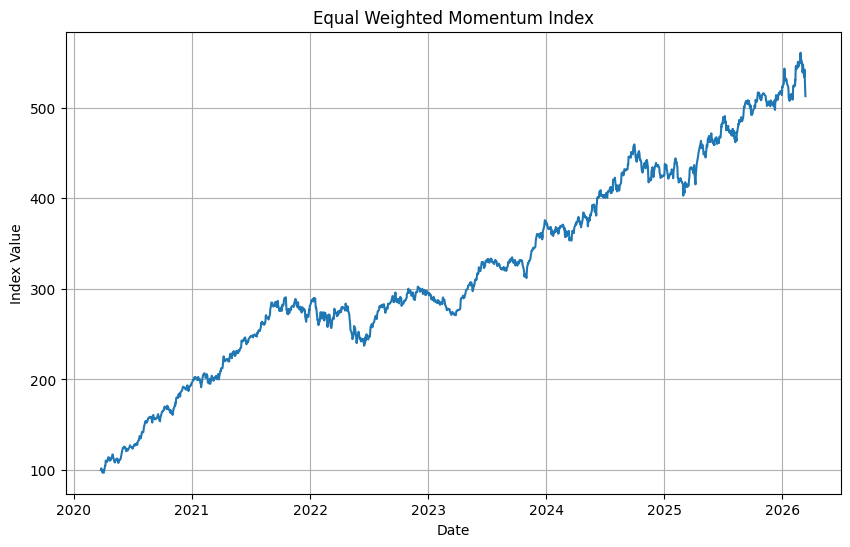

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(equal_weight_index)

plt.title("Equal Weighted Momentum Index")
plt.xlabel("Date")
plt.ylabel("Index Value")

plt.grid(True)

plt.show()